## code for Solution for PDE 

In [1]:
import numpy as np
import pandas as pd

L = 1.0
T = 0.5
nx = 20
nt = 100
alpha = 0.01

dx = L / (nx - 1)
dt = T / nt

r = alpha * dt / dx**2

x = np.linspace(0, L, nx)
t_values = np.linspace(0, T, nt)

u = np.sin(np.pi * x)

data = []

for n in range(nt):
    t = n * dt
    u_new = u.copy()
    
    for i in range(1, nx-1):
        u_new[i] = u[i] + r * (u[i+1] - 2*u[i] + u[i-1])
    
    u_new[0] = 0
    u_new[-1] = 0
    
    u = u_new
    
    for i in range(nx):
        data.append([x[i], t, u[i]])

df = pd.DataFrame(data, columns=['x', 't', 'u'])

df.to_csv("heat_data.csv", index=False)

print("Dataset generated and saved as heat_data.csv")

Dataset generated and saved as heat_data.csv


In [2]:
df

,x,t,u
0,0.000000,0.000,0.000000
1,0.052632,0.000,0.164514
2,0.105263,0.000,0.324540
3,0.157895,0.000,0.475713
4,0.210526,0.000,0.613910
...,...,...,...
1995,0.789474,0.495,0.584697
1996,0.842105,0.495,0.453076
1997,0.894737,0.495,0.309096
1998,0.947368,0.495,0.156685


First 5 rows:


,x,t,u
0,0.000000,0.0,0.000000
1,0.052632,0.0,0.164514
2,0.105263,0.0,0.324540
3,0.157895,0.0,0.475713
4,0.210526,0.0,0.613910



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       2000 non-null   float64
 1   t       2000 non-null   float64
 2   u       2000 non-null   float64
dtypes: float64(3)
memory usage: 47.0 KB

Summary Statistics:


,x,t,u
count,2000.000000,2000.000000,2000.000000
mean,0.500000,0.247500,0.588648
std,0.303564,0.144366,0.325085
min,0.000000,0.000000,0.000000
25%,0.250000,0.123750,0.316763
50%,0.500000,0.247500,0.657140
75%,0.750000,0.371250,0.893169
max,1.000000,0.495000,0.996094



Missing values:


,Missing Count
x,0
t,0
u,0



After Normalization:


,x,t,u
0,0.000000,0.0,0.000000
1,0.052632,0.0,0.165159
2,0.105263,0.0,0.325812
3,0.157895,0.0,0.477579
4,0.210526,0.0,0.616318



Correlation Matrix:


,x,t,u
x,1.000000e+00,-8.487569e-16,1.645347e-16
t,-8.487569e-16,1.000000e+00,-2.574684e-02
u,1.645347e-16,-2.574684e-02,1.000000e+00


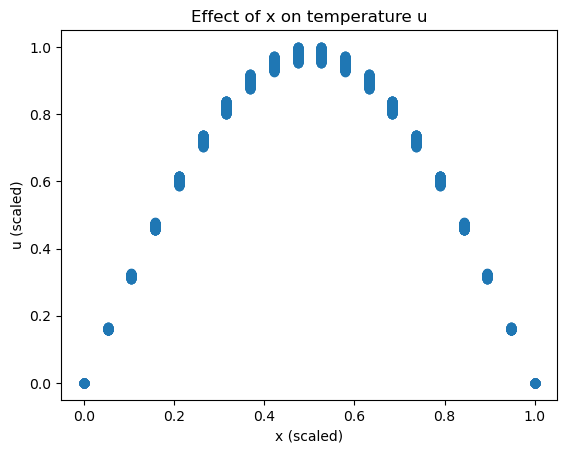


Input features (X):


,x,t
0,0.000000,0.0
1,0.052632,0.0
2,0.105263,0.0
3,0.157895,0.0
4,0.210526,0.0



Output (y):


0    0.000000
1    0.165159
2    0.325812
3    0.477579
4    0.616318
Name: u, dtype: float64

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display

# Load dataset
df = pd.read_csv("heat_data.csv")

# -------------------------------
# Step 1: Inspect Data
# -------------------------------
print("First 5 rows:")
display(df.head())

print("\nData Info:")
df.info()   # info prints text (this is normal)

print("\nSummary Statistics:")
display(df.describe())

# -------------------------------
# Step 2: Clean Data
# -------------------------------
print("\nMissing values:")
display(df.isnull().sum().to_frame(name="Missing Count"))

df = df.drop_duplicates()

# -------------------------------
# Step 3: Normalize Data
# -------------------------------
scaler = MinMaxScaler()
df[['x', 't', 'u']] = scaler.fit_transform(df[['x', 't', 'u']])

print("\nAfter Normalization:")
display(df.head())

# -------------------------------
# Step 4: Feature Selection (Correlation)
# -------------------------------
print("\nCorrelation Matrix:")
display(df.corr())

# -------------------------------
# Step 5: Visualization
# -------------------------------
plt.figure()
plt.scatter(df['x'], df['u'])
plt.xlabel("x (scaled)")
plt.ylabel("u (scaled)")
plt.title("Effect of x on temperature u")
plt.show()

# -------------------------------
# Step 6: Prepare ML Data
# -------------------------------
X = df[['x', 't']]
y = df['u']

print("\nInput features (X):")
display(X.head())

print("\nOutput (y):")
display(y.head())